<a href="https://colab.research.google.com/github/edrodriguezdunad-tech/Phase-4-Project-Execution/blob/main/Tarea4_EdwinRodriguez_Grupo10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CURSO: PROGRAMACIÓN PARA EL ANÁLISIS DE DATOS

## **Nombre del Estudiante:** Edwin David Rodríguez

*Grupo: G10*

**Nombre del Tutor:** Felipe Alexander Pipicano Guzman

# ***UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA – UNAD***

**Fecha:** 13 de abril de 2026


# Objetivos

- Analizar el uso de los movimientos f3 y g4 en niveles de juego superiores al principiante.
- Determinar la apertura más usada por los jugadores analizados en el dataset.
- Comprobar si las aperturas más usadas toman el centro del tablero.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/openings.csv')
print(df.head())

Mounted at /content/drive
   Unnamed: 0                                            Opening Colour  \
0           0                 Alekhine Defense, Balogh Variation  white   
1           1               Alekhine Defense, Brooklyn Variation  black   
2           2               Alekhine Defense, Exchange Variation  white   
3           3                Alekhine Defense, Four Pawns Attack  white   
4           4  Alekhine Defense, Four Pawns Attack, Fianchett...  black   

   Num Games  ECO Last Played  Perf Rating  Avg Player  Player Win %  Draw %  \
0        692  B03  2018-06-22         2247        2225          40.8    24.3   
1        228  B02  2018-06-27         2145        2193          29.8    22.4   
2       6485  B03  2018-07-06         2244        2194          40.8    27.7   
3        881  B03  2018-06-20         2187        2130          39.7    23.2   
4        259  B03  2018-05-20         2122        2178          37.8    21.2   

   ...  move2b move3w move3b move4w move4b

#**Desarrollo del Análisis Exploratorio de Datos (EDA)**

##**Parte 1: Parámetros y métricas descriptivas**
###1. Para cada variable numérica, determine e interprete las siguientes métricas:
* Cantidad de datos no nulos (count).
* Media (mean).
* Desviación estándar (std).
* Mínimo y máximo.
* Percentiles 25, 50 (mediana) y 75.

###2. Para cada variable categórica, determine e interprete:
* Cantidad de valores no nulos.
*	Cantidad de valores únicos.
*	Moda.
*	Frecuencia de la moda
###3. Genere la matriz de correlación entre variables numéricas:
* Preséntela en formato tabular e identifique las variables que presentan mayor correlación y comente su posible relación.
*	Visualice la matriz de correlación mediante un heatmap utilizando la librería seaborn (sns.heatmap), destacando gráficamente las asociaciones más fuertes entre variables.
*	Realice un análisis interpretativo de la matriz de correlación, comentando las posibles relaciones causales, redundancias o asociaciones significativas entre las variables.
###4. Realice una visualización de estadísticas por grupo:
*	Agrupe las variables numéricas por una variable categórica de interés (por ejemplo: región, sector, categoría, etc.) y obtenga estadísticas con .groupby().describe().
###5. Identifique valores atípicos (outliers) en al menos una variable numérica usando el método del rango intercuartílico (IQR). Muestre los valores y comente sus posibles causas o consecuencias.
###6. En una celda Markdown, escriba un análisis reflexivo general de esta sección:
* ¿Qué variables tienen más variabilidad?
*	¿Cuáles muestran comportamientos inesperados?
*	¿Qué insights preliminares ofrece esta exploración?


### 1. Para cada variable numérica, determine e interprete las siguientes métricas:
* Cantidad de datos no nulos (count).
* Media (mean).
* Desviación estándar (std).
* Mínimo y máximo.
* Percentiles 25, 50 (mediana) y 75.

In [ ]:
print('Valores nulos en numero de juegos , victorias de blancas, victorias de negras:')
print(df[['Num Games', 'White_Wins', 'Black_Wins']].isnull().sum())
print('Media de numero de juegos, victorias de blancas y negras:')
print(df[['Num Games', 'White_Wins', 'Black_Wins']].mean())
print('Desviación estándar de numero de juegos, victorias de blancas y negras:')
print(df[['Num Games', 'White_Wins', 'Black_Wins']].std())
print('Mínimo y máximo de numero de juegos, victorias de blancas y negras:')
print(df[['Num Games', 'White_Wins', 'Black_Wins']].min())
print(df[['Num Games', 'White_Wins', 'Black_Wins']].max())
print('Percentiles 25, 50 (mediana) y 75 de numero de juegos, victorias de blancas y negras:')
print(df[['Num Games', 'White_Wins', 'Black_Wins']].quantile([0.25, 0.5, 0.75]))

Valores nulos en numero de juegos , victorias de blancas, victorias de negras:
Num Games     0
White_Wins    0
Black_Wins    0
dtype: int64
Media de numero de juegos, victorias de blancas y negras:
Num Games     1846.019108
White_Wins     708.835970
Black_Wins     557.051955
dtype: float64
Desviación estándar de numero de juegos, victorias de blancas y negras:
Num Games     2739.103462
White_Wins    1037.027669
Black_Wins     866.788831
dtype: float64
Mínimo y máximo de numero de juegos, victorias de blancas y negras:
Num Games     100.000
White_Wins     21.000
Black_Wins      8.946
dtype: float64
Num Games     22482.000
White_Wins     8295.858
Black_Wins     8700.534
dtype: float64
Percentiles 25, 50 (mediana) y 75 de numero de juegos, victorias de blancas y negras:
      Num Games  White_Wins  Black_Wins
0.25     314.75    124.7405    91.02625
0.50     788.50    310.2740   230.95200
0.75    2225.00    824.2430   651.26275


### 2. Para cada variable categórica, determine e interprete:
* Cantidad de valores no nulos.
* Cantidad de valores únicos.
* Moda.
* Frecuencia de la moda

In [ ]:
print('Valores no nulos en variables ECO, primer movimiento de blancas, primer movimiento de negras:')
print(df[['ECO', 'move1w', 'move1b']].count())
print('Valores únicos en variables ECO, primer movimiento de blancas, primer movimiento de negras:')
print(df[['ECO', 'move1w', 'move1b']].nunique())
print('Moda en variables ECO, primer movimiento de blancas, primer movimiento de negras:')
print(df[['ECO', 'move1w', 'move1b']].mode())
print('Frecuencia de la moda en variables ECO, primer movimiento de blancas, primer movimiento de negras:')
print(df[['ECO', 'move1w', 'move1b']].value_counts())

Valores no nulos en variables ECO, primer movimiento de blancas, primer movimiento de negras:
ECO       1884
move1w    1884
move1b    1869
dtype: int64
Valores únicos en variables ECO, primer movimiento de blancas, primer movimiento de negras:
ECO       493
move1w     16
move1b     13
dtype: int64
Moda en variables ECO, primer movimiento de blancas, primer movimiento de negras:
   ECO move1w move1b
0  A00     e4    Nf6
Frecuencia de la moda en variables ECO, primer movimiento de blancas, primer movimiento de negras:
ECO  move1w  move1b
B06  e4      g6        22
B01  e4      d5        22
C42  e4      e5        21
C41  e4      e5        21
C44  e4      e5        18
                       ..
A01  b3      c5         1
             b6         1
             Nf6        1
A00  g3      g6         1
             f5         1
Name: count, Length: 552, dtype: int64


### 3. Genere la matriz de correlación entre variables numéricas:
* Preséntela en formato tabular e identifique las variables que presentan mayor correlación y comente su posible relación.
* Visualice la matriz de correlación mediante un heatmap utilizando la librería seaborn (sns.heatmap), destacando gráficamente las asociaciones más fuertes entre variables.
* Realice un análisis interpretativo de la matriz de correlación, comentando las posibles relaciones causales, redundancias o asociaciones significativas entre las variables.

Matriz de Correlación (formato tabular):


,Num Games,White_Wins,Black_Wins
Num Games,1.000000,0.989485,0.977510
White_Wins,0.989485,1.000000,0.952201
Black_Wins,0.977510,0.952201,1.000000



Variables con las correlaciones más fuertes:
White_Wins  Num Games     0.989485
Black_Wins  Num Games     0.977510
            White_Wins    0.952201
Num Games   Num Games          NaN
dtype: float64


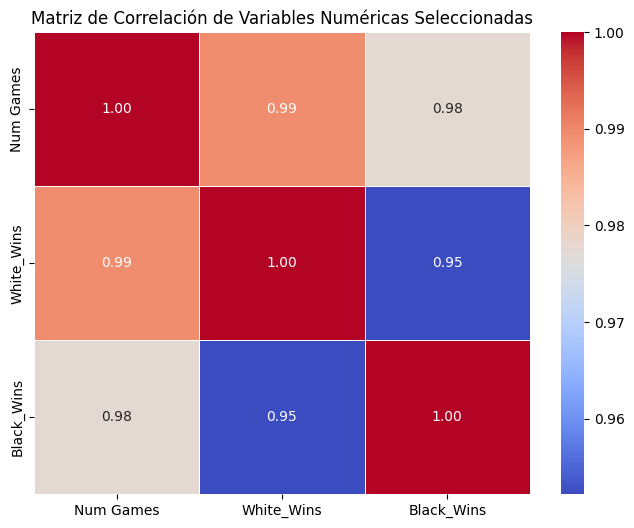

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = ['Num Games', 'White_Wins', 'Black_Wins']
correlation_matrix = df[numeric_cols].corr()

print('Matriz de Correlación (formato tabular):')
display(correlation_matrix)


upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))


most_correlated = upper_tri.unstack().sort_values(ascending=False).drop_duplicates()

print('\nVariables con las correlaciones más fuertes:')
print(most_correlated.head(10))


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas Seleccionadas')
plt.show()

### Análisis Interpretativo de la Matriz de Correlación


**Observaciones**

Las variables presentan una correlación alta y positiva, pero esto responde a que la variable `Num Games` es generadora de las otras. `White_Wins` y `Black_Wins` son parte de un conjunto llamado `Num Games`. Al realizar un análisis sobre posiciones de ajedrez, una línea de inicio no es garantía de una victoria solo por ser jugada de esta manera. Además, como se alcanza a ver en la impresión de las cabeceras, hay una parte del conjunto que no se está considerando, y es cuando los juegos terminan en empate. La lógica observada es que `Num Games` contiene los conjuntos `White_Wins` y `Black_Wins`; entre más se juegue, más aumentará el número de triunfos de un color o de otro, así como la cantidad de empates que no se encuentra evaluada en este análisis.

### 4. Realice una visualización de estadísticas por grupo:
* Agrupe las variables numéricas por una variable categórica de interés (por ejemplo: región, sector, categoría, etc.) y obtenga estadísticas con .groupby().describe().

In [ ]:
print('Estadísticas descriptivas agrupadas por primer movimiento de blancas:')
numerical_vars = ['Num Games', 'White_Wins', 'Black_Wins']

df['move1w'] = df['move1w'].astype('category')

grouped_stats = df.groupby('move1w', observed=False)[numerical_vars].describe()
display(grouped_stats)

Estadísticas descriptivas agrupadas por primer movimiento de blancas:


Num Games                                                              \
           count         mean          std     min      25%     50%      75%   
move1w                                                                         
Nc3          5.0   896.000000  1094.193310   137.0   277.00   381.0   901.00   
Nf3         49.0  2918.285714  4697.127695   118.0   463.00   852.0  3001.00   
a3           1.0  1308.000000          NaN  1308.0  1308.00  1308.0  1308.00   
b3           7.0  2304.857143  2444.296383   185.0   645.00   995.0  3409.50   
b4          11.0   565.000000   844.626781   128.0   204.00   329.0   395.00   
c3           1.0   799.000000          NaN   799.0   799.00   799.0   799.00   
c4         103.0  2515.038835  3056.434578   119.0   550.50  1376.0  3236.50   
d3           2.0   623.500000   548.007755   236.0   429.75   623.5   817.25   
d4         734.0  1783.325613  2424.318969   102.0   356.75   887.0  2149.00   
e3           1.0  1713.000000          NaN  1713.0  1713.00  1713.0  1713.00   
e4         951.0  1786.335436  2808.767093   100.0   267.00   690.0  2106.00   
f4           5.0  3263.000000  3681.996741   493.0   538.00   738.0  6728.00   
g3           8.0  2347.125000  2528.517829   170.0   445.75  1516.5  3473.00   
g4           4.0   199.250000   129.926582   112.0   128.50   146.5   217.25   
h3           1.0   183.000000          NaN   183.0   183.00   183.0   183.00   
h4           1.0   121.000000          NaN   121.0   121.00   121.0   121.00   

                White_Wins               ...                       Black_Wins  \
            max      count         mean  ...         75%       max      count   
move1w                                   ...                                    
Nc3      2784.0        5.0   331.805200  ...   267.59700  1024.512        5.0   
Nf3     20045.0       49.0  1101.343837  ...  1287.20100  7854.660       49.0   
a3       1308.0        1.0   466.956000  ...   466.95600   466.956        1.0   
b3       6845.0        7.0   864.444571  ...  1294.89300  2505.270        7.0   
b4       3071.0       11.0   209.866909  ...   137.38700  1108.631       11.0   
c3        799.0        1.0   258.077000  ...   258.07700   258.077        1.0   
c4      14610.0      103.0   947.983660  ...  1181.02400  5785.560      103.0   
d3       1011.0        2.0   221.478000  ...   288.67500   355.872        2.0   
d4      17885.0      734.0   687.833723  ...   819.60800  7082.460      734.0   
e3       1713.0        1.0   553.299000  ...   553.29900   553.299        1.0   
e4      22482.0      951.0   687.317105  ...   794.06700  8295.858      951.0   
f4       7818.0        5.0  1131.979200  ...  2321.16000  2650.302        5.0   
g3       7551.0        8.0   942.918000  ...  1440.07350  2929.788        8.0   
g4        392.0        4.0    69.770750  ...    88.02625   136.024        4.0   
h3        183.0        1.0    66.978000  ...    66.97800    66.978        1.0   
h4        121.0        1.0    41.019000  ...    41.01900    41.019        1.0   

                                                                            \
               mean          std      min        25%       50%         75%   
move1w                                                                       
Nc3      329.342000   413.660623   29.044   75.05700  111.9080   411.75700   
Nf3      847.169571  1347.102378   46.964  125.01000  291.3300   897.67200   
a3       506.196000          NaN  506.196  506.19600  506.1960   506.19600   
b3       789.607143   864.586162   64.010  220.70300  337.4040  1123.80500   
b4       227.606182   367.821008   49.024   79.53000  108.9850   165.44400   
c3       329.987000          NaN  329.987  329.98700  329.9870   329.98700   
c4       717.444155   865.548419   27.040  149.39150  356.0400   927.79900   
d3       251.187500   212.385886  101.008  176.09775  251.1875   326.27725   
d4       505.072895   726.371760    8.946   99.13350  237.4445   597.17550   
e3       8

### 5. Identifique valores atípicos (outliers) en al menos una variable numérica usando el método del rango intercuartílico (IQR). Muestre los valores y comente sus posibles causas o consecuencias.

In [ ]:
variable_outliers_num_games = 'Num Games'


Q1_num_games = df[variable_outliers_num_games].quantile(0.25)
Q3_num_games = df[variable_outliers_num_games].quantile(0.75)


IQR_num_games = Q3_num_games - Q1_num_games


lower_bound_num_games = Q1_num_games - 1.5 * IQR_num_games
upper_bound_num_games = Q3_num_games + 1.5 * IQR_num_games


outliers_num_games = df[(df[variable_outliers_num_games] < lower_bound_num_games) | (df[variable_outliers_num_games] > upper_bound_num_games)]

print(f"Análisis de Outliers para la variable '{variable_outliers_num_games}' usando el método IQR")
print(f"Q1: {Q1_num_games}")
print(f"Q3: {Q3_num_games}")
print(f"IQR: {IQR_num_games}")
print(f"Límite inferior para outliers: {lower_bound_num_games}")
print(f"Límite superior para outliers: {upper_bound_num_games}")

print(f"\nCantidad de outliers detectados: {len(outliers_num_games)}")
print("\nPrimeros 10 outliers (si existen) en 'Num Games':")
display(outliers_num_games[['Opening', 'Num Games']].head(10))


Análisis de Outliers para la variable 'Num Games' usando el método IQR
Q1: 314.75
Q3: 2225.0
IQR: 1910.25
Límite inferior para outliers: -2550.625
Límite superior para outliers: 5090.375

Cantidad de outliers detectados: 164

Primeros 10 outliers (si existen) en 'Num Games':


,Opening,Num Games
2,"Alekhine Defense, Exchange Variation",6485
17,"Alekhine Defense, Modern Variation, Main Line",5096
67,"Benoni Defense, General",5336
73,"Benoni Defense, Modern Variation",5208
85,"Bird Opening, Dutch Variation",7818
88,"Bird Opening, General",6728
112,"Bogo-Indian Defense, GrÃ¼nfeld Variation",8285
113,"Bogo-Indian Defense, Nimzowitsch Variation",7509
127,"Caro-Kann Defense, Advance Variation",5840
131,"Caro-Kann Defense, Advance Variation, Short Va...",8521


Los valores atípicos (_outliers_) identificados en la variable `Num Games` representan aperturas de ajedrez que se han jugado en mayor número de ocasiones en comparación con el resto de las posiciones. Es de denotar que los _outliers_ visualizados corresponden a las aperturas más populares en este conjunto de juegos, lo cual en sí ya es un indicador muy fuerte, ya que son los juegos que mayor teoría tienen. Esto, en el caso de buscar una manera de juego, influye mucho, pues una recomendación en el ajedrez es que, si el rival es muy teórico, se debe buscar la forma de sacarlo de su base teórica, es decir, buscar aperturas con poca teoría o poco conocidas para quitarle esta ventaja de juego. Para el estudio estadístico, estos _outliers_ alteran métricas como la media y la desviación estándar, lo cual dificultaría el manejo de las variables para modelos predictivos, pero los datos obtenidos al realizar la verificación, por sí mismos, ya presentan gran utilidad.

### 6. En una celda Markdown, escriba un análisis reflexivo general de esta sección:
* ¿Qué variables tienen más variabilidad?

Como las variables de partidas ganadas por color son generadas directamente por las de número de juegos, estas presentan una variabilidad similar.

* ¿Cuáles muestran comportamientos inesperados?

Mi mayor sorpresa fue cuando, al buscar dentro de las variables categóricas de primer movimiento de blancas y negras, no encontré en el primer lugar de la moda de estas variables los movimientos *1.e4.e5* en lugar de los movimientos *1.e4.Nf6*. Esto indicó que las partidas se iniciaron con aperturas más enfocadas a posicionar piezas que a realizar ataques tempranos. En cuanto al comportamiento de las variables como datos, fue inesperado no obtener _outliers_ bajos.

* ¿Qué _insights_ preliminares ofrece esta exploración?

La base de datos escogida contempla partidas de jugadores de nivel medio. Se encuentran 1884 aperturas diferentes donde, para la primera jugada de blancas, se jugaron 16 movimientos con todas las casillas posibles para el primer movimiento de peones, menos *a4* y *f3*, lo cual indica que los jugadores consideraron ese movimiento de piezas una desventaja. Eso nos dejaría con 14 movimientos de peón y los movimientos de caballos *Nc3* y *Nf3* como los movimientos de apertura de todo el _dataset_. Para concluir, el análisis de este _dataset_ requiere que el análisis de variables numéricas y categóricas en conjunto para obtener resultados notables que vayan más allá de la determinación de puntos mínimos o máximos de las variables.

##**Parte 2: Escalamiento, estandarización y codificación**

###1. Seleccione al menos una variable continua y categorícela de acuerdo con rangos definidos por usted.
*	Justifique la elección de los rangos (puede basarse en percentiles o valores relevantes del dominio del problema).
###2. Estandarice o escale al menos dos variables numéricas que tengan diferentes magnitudes o unidades:
*	Puede	usar:	MinMaxScaler	o	StandardScaler	de sklearn.preprocessing.
###3. Presente una tabla comparativa de estadísticas (media, desviación, rango) antes y después de escalar.
###4. Aplique	codificación	a	una	variable	categórica,	usando LabelEncoder o pd.get_dummies().
###5. Analice brevemente los beneficios y riesgos de transformar o codificar variables en etapas iniciales del análisis de datos.


### 1. Seleccione al menos una variable continua y categorícela de acuerdo con rangos definidos por usted.
* Justifique la elección de los rangos (puede basarse en percentiles o valores relevantes del dominio del problema).

In [ ]:
bins = [0, 1000, 1800, 2200, 2500, float('inf')] # El último bin es para 2500+ Elo
labels = ['Principiante (0-1000 Elo)', 'Jugador de Club (1000-1800 Elo)', 'Experto/Candidato a Maestro (1800-2200 Elo)', 'Maestro (2200-2500 Elo)', 'Gran Maestro (2500+ Elo)']


df['Player_Level'] = pd.cut(df['Avg Player'], bins=bins, labels=labels, right=False)

print("Primeras filas con la nueva variable categórica 'Player_Level':")
display(df[['Avg Player', 'Player_Level']].head())

Primeras filas con la nueva variable categórica 'Player_Level':


,Avg Player,Player_Level
0,2225,Maestro (2200-2500 Elo)
1,2193,Experto/Candidato a Maestro (1800-2200 Elo)
2,2194,Experto/Candidato a Maestro (1800-2200 Elo)
3,2130,Experto/Candidato a Maestro (1800-2200 Elo)
4,2178,Experto/Candidato a Maestro (1800-2200 Elo)


### Justificación de la categorización de `Avg Player`

La variable continua Avg Player (rating promedio del jugador) ha sido categorizada en Player_Level utilizando los rangos de rating Elo reconocidos a nivel mundial por la FIDE. Este enfoque es adecuado en el análisis de ajedrez, ya que el sistema Elo constituye una métrica estándar para clasificar la fuerza de los jugadores, lo que permite agrupar las aperturas en categorías con significado claro dentro del dominio. Además, al transformar una escala numérica continua en categorías descriptivas como Principiante, Jugador de Club, Experto, Maestro y Gran Maestro, se facilita la interpretación y se comunican los hallazgos de manera más intuitiva. Este método también posibilita un análisis segmentado entre diversos niveles de destreza, lo que permite determinar, por ejemplo, cuáles aperturas son más comunes en cada conjunto de jugadores. En última instancia, esta categorización es una base útil para futuros modelos de predicción o clasificación, pues numerosas técnicas se favorecen del empleo de variables categóricas e incluso las necesitan.

### 2. Estandarice o escale al menos dos variables numéricas que tengan diferentes magnitudes o unidades:
* Puede usar: MinMaxScaler o StandardScaler de sklearn.preprocessing.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Variables a estandarizar
variables_to_scale = ['Num Games', 'Draw %']

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar el escalado y crear nuevas columnas para los valores estandarizados
df[['Num Games_scaled', 'Draw_percent_scaled']] = scaler.fit_transform(df[variables_to_scale])

print("Primeras filas con las variables estandarizadas:")
display(df[['Num Games', 'Num Games_scaled', 'Draw %', 'Draw_percent_scaled']].head())

Primeras filas con las variables estandarizadas:


,Num Games,Num Games_scaled,Draw %,Draw_percent_scaled
0,692,-0.421425,24.3,-0.698188
1,228,-0.590868,22.4,-0.934480
2,6485,1.694063,27.7,-0.275350
3,881,-0.352406,23.2,-0.834988
4,259,-0.579547,21.2,-1.083717


### 3. Presente una tabla comparativa de estadísticas (media, desviación, rango) antes y después de escalar.

In [ ]:
import pandas as pd


stats_before = df[['Num Games', 'Draw %']].agg(['mean', 'std', 'min', 'max']).transpose()
stats_before['range'] = stats_before['max'] - stats_before['min']
stats_before = stats_before.drop(columns=['min', 'max'])
stats_before.columns = ['Media (Original)', 'Desviación Estándar (Original)', 'Rango (Original)']


stats_after = df[['Num Games_scaled', 'Draw_percent_scaled']].agg(['mean', 'std', 'min', 'max']).transpose()
stats_after['range'] = stats_after['max'] - stats_after['min']
stats_after = stats_after.drop(columns=['min', 'max'])
stats_after.columns = ['Media (Escalada)', 'Desviación Estándar (Escalada)', 'Rango (Escalado)']


comparison_table = pd.concat([stats_before, stats_after], axis=1)

print("Tabla Comparativa de Estadísticas antes y después de escalar:")
display(comparison_table)

Tabla Comparativa de Estadísticas antes y después de escalar:


,Media (Original),Desviación Estándar (Original),Rango (Original),Media (Escalada),Desviación Estándar (Escalada),Rango (Escalado)
Num Games,1846.019108,2739.103462,22382.0,NaN,NaN,NaN
Draw %,29.914066,8.043043,64.5,NaN,NaN,NaN
Num Games_scaled,NaN,NaN,NaN,-3.205740e-17,1.000265,8.173456
Draw_percent_scaled,NaN,NaN,NaN,-1.131437e-16,1.000265,8.021482


### 4. Aplique codificación a una variable categórica, usando LabelEncoder o pd.get_dummies().

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Inicializar el LabelEncoder
label_encoder = LabelEncoder()

# Aplicar Label Encoding a la columna 'Colour'
df['Colour_encoded'] = label_encoder.fit_transform(df['Colour'])

print("Primeras filas con la variable 'Colour' codificada:")
display(df[['Colour', 'Colour_encoded']].head())

Primeras filas con la variable 'Colour' codificada:


,Colour,Colour_encoded
0,white,1
1,black,0
2,white,1
3,white,1
4,black,0


### 5. Analice brevemente los beneficios y riesgos de transformar o codificar variables en etapas iniciales del análisis de datos.

**Beneficios de transformar o codificar variables:**

Las variables codificadas aseguran la compatibilidad con algoritmos de aprendizaje automático, dado que muchos de estos precisan entradas en forma numérica. Este procedimiento no solo posibilita que modelos como las redes neuronales, la regresión lineal o los SVM procesen variables categóricas, sino que además mejora el rendimiento a través de técnicas de escalado o estandarización (como StandardScaler o MinMaxScaler), sobre todo en algoritmos que son sensibles a gradientes o distancias. Además, la normalización contribuye a disminuir los sesgos que resultan de escalas distintas, garantizando que todas las variables aporten al modelo de manera balanceada. Además, estas transformaciones tienen el potencial de simplificar la interpretación al hacer ciertas relaciones más lineales y, en algunas ocasiones, atenuar el efecto de los valores atípicos a través de transformaciones como la logarítmica.

**Riesgos de transformar o codificar variables:**

A pesar de ser fundamentales para el modelado, las técnicas de transformación y codificación de variables tienen diversas restricciones. En primer lugar, suponen una pérdida de interpretabilidad, pues las variables que se obtienen no son intuitivas en el contexto original, lo que complica la explicación de los resultados. Además, pueden introducir sesgos sin querer, en particular cuando se utilizan métodos como *LabelEncoder* en variables nominales, lo que produce relaciones ordinales artificiales que el modelo puede malinterpretar. Por otra parte, métodos como el One-Hot Encoding producen un crecimiento notorio de la dimensionalidad (curse of dimensionality), lo cual hace que aumenten los costos computacionales, la complejidad del modelo y el peligro de sobreajuste. Esta ampliación también implica un incremento en el uso de memoria y en el tiempo que tarda el procesamiento, sobre todo cuando se trata de conjuntos de datos grandes. Por ultimo, en los modelos lineales, estas codificaciones pueden ocasionar problemas de multicolinealidad, lo que resulta en inestabilidad de los coeficientes y complica el análisis de los efectos de cada variable.

##**Parte 3: Gráficos y visualización científica**


Realice los siguientes gráficos, utilizando matplotlib, seaborn, pandas.plot o librerías equivalentes. Cada gráfico debe estar acompañado de:



*	Título descriptivo
*	Etiquetas en los ejes •	Leyenda si aplica
*	Un comentario o interpretación del gráfico

##**Gráficos solicitados:**

1. Diagrama de barras para visualizar frecuencias de una variable categórica.
2. Diagrama de cajas (boxplot) para analizar la distribución y detectar valores atípicos en una variable numérica.
3. Gráfico de pie (torta) para mostrar proporciones de una variable categórica (requiere agrupamiento por conteo).
4. Scatter plot o pairplot para analizar la relación entre variables numéricas (especialmente aquellas correlacionadas en el concepto 1).
5. Gráfico de violín usando la variable continua categorizada en la Parte 2.
6. Comparación de histogramas de las variables que fueron estandarizadas o escaladas.
7. Gráfico de densidad (opcional) con kdeplot para visualizar la forma de distribución de una o más variables numéricas.
8. Gráfico combinado (por ejemplo: barras con hue, scatter con tamaño de punto, etc.) que permita relacionar dos o más dimensiones en un mismo gráfico.
##**Puntuación adicional (opcional)**

Si su base de datos contiene datos geoespaciales (latitud y longitud), genere una visualización interactiva de mapa usando la librería Folium.

*	Puede marcar puntos, usar CircleMarker, agrupar ubicaciones, o definir capas.
*	Agregue un comentario sobre cómo esta vista espacial mejora la interpretación de los datos.




##**Gráficos y visualización científica**

##**Gráficos solicitados**

###1. Diagrama de barras para visualizar frecuencias de una variable categórica.

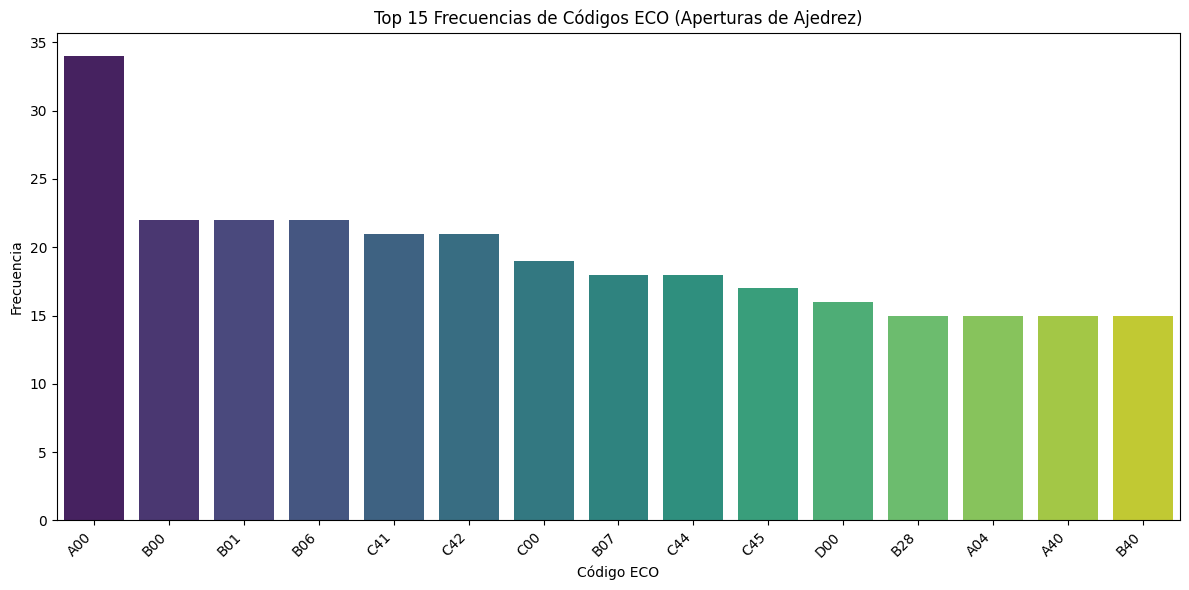

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

eco_counts = df['ECO'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=eco_counts.index, y=eco_counts.values, hue=eco_counts.index, palette='viridis', legend=False)
plt.title('Top 15 Frecuencias de Códigos ECO (Aperturas de Ajedrez)')
plt.xlabel('Código ECO')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretación del Diagrama de Barras de Códigos ECO

El gráfico de barras que muestra los códigos ECO representa las 15 aperturas de ajedrez más comunes en el conjunto de datos; cada barra indica la frecuencia con la que se registra una apertura determinada. Se observa una notable concentración en unas pocas aperturas predominantes, siendo el código **A00** el que se usa más a menudo, seguido de **B00, B01 y B06**. Esto señala que esas aperturas son muy empleadas y que probablemente constituyen líneas esenciales o bien investigadas. En particular, la gran cantidad de **A00**, que comprende aperturas no convencionales o de flanco, indica una tendencia hacia tácticas menos tradicionales que no priorizan el control inmediato del centro utilizando los peones "e" o "d".

A pesar de esta concentración, se observa una diversidad significativa en las decisiones iniciales, puesto que dentro del grupo más común hay 15 códigos diferentes. Esto señala que los jugadores investigan diversas estrategias en la etapa inicial del juego. Este estudio facilita la identificación de tendencias importantes dentro del conjunto de datos, lo que resulta útil tanto para jugadores que quieren prepararse frente a las aperturas más probables como para sistemas o motores de análisis orientados a líneas populares. Además, la frecuencia alta de algunas aperturas podría relacionarse con su versatilidad o fortaleza; en cambio, las que son menos frecuentes podrían significar un desarrollo teórico menor o un riesgo más elevado. Para llevar a cabo un análisis más detallado, sería importante examinar la eficacia de estas aperturas a través de su conexión con los porcentajes de empate y victoria.

###2. Diagrama de cajas (boxplot) para analizar la distribución y detectar valores atípicos en una variable numérica.

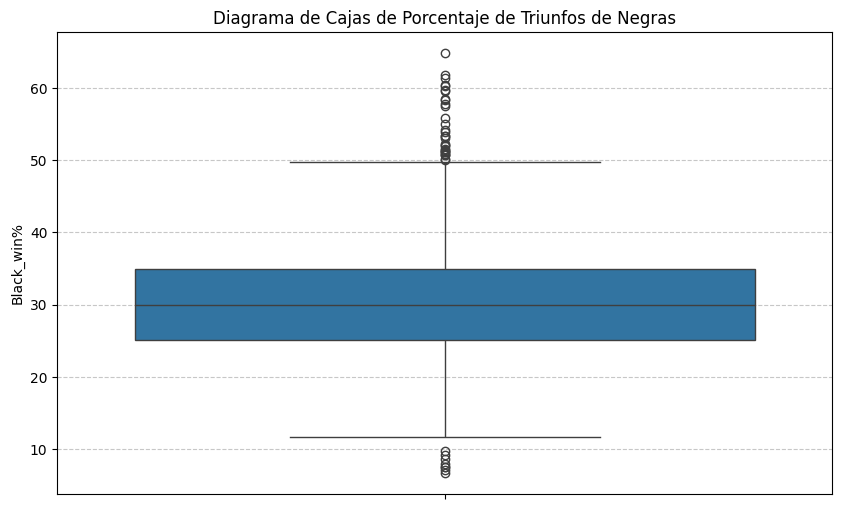

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Black_win%'])
plt.title('Diagrama de Cajas de Porcentaje de Triunfos de Negras')
plt.ylabel('Black_win%')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Análisis del Diagrama de Cajas para 'Black_win%'

El boxplot de Black_win% proporciona una perspectiva completa sobre cómo se distribuye el porcentaje de victorias de las piezas negras en diferentes aperturas. La línea central, que representa la mediana, señala el punto medio de los datos y posibilita el análisis del rendimiento promedio de las negras, constituyéndose en una medida sólida ante valores extremos. La caja, que cubre el rango intercuartílico (IQR) entre el primer y tercer cuartil, congrega la mitad de los valores y muestra el grado de dispersión en la región central: una caja más compacta implica resultados estables, mientras que una más extensa señala un incremento en la variabilidad.Los bigotes amplían esta perspectiva a los valores que no son atípicos, revelando el rango anticipado de rendimiento. Por su parte, los puntos que quedan fuera de ellos (outliers) constituyen aperturas con resultados extraordinariamente altos o bajos para las negras.

De este análisis se pueden obtener percepciones fundamentales acerca del comportamiento del conjunto de datos. Si la mediana está en una posición determinada, se puede deducir si las negras tienen un rendimiento limitado o bueno; por otra parte, la forma de la distribución (si es sesgada o simétrica) muestra si hay tendencias hacia resultados más altos o más bajos. La existencia de varios valores atípicos y la dispersión total muestran cuán variable es el rendimiento entre aperturas, resaltando situaciones extremas que podrían tener relevancia estratégica. Específicamente, estos valores atípicos permiten reconocer aperturas que son especialmente favorables o desfavorables para las negras, lo cual es beneficioso para los analistas interesados en profundizar en patrones de desempeño y efectividad, así como para los jugadores que quieren optimizar su repertorio.

###3. Gráfico de pie (torta) para mostrar proporciones de una variable categórica (requiere agrupamiento por conteo).

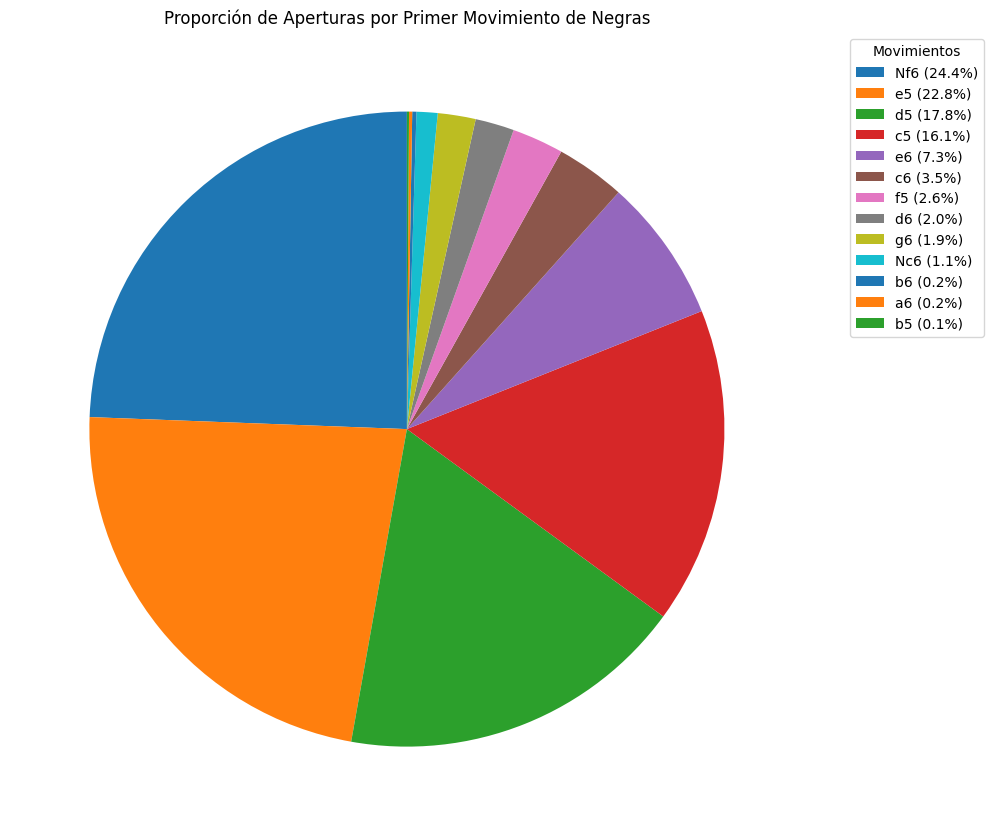

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

move1b_counts = df['move1b'].value_counts().dropna() # Get counts, drop NaNs
move1b_percentages = df['move1b'].value_counts(normalize=True).dropna() * 100

plt.figure(figsize=(10, 10))

# Plot the pie chart without labels on the slices
plt.pie(move1b_counts, startangle=90)

plt.title('Proporción de Aperturas por Primer Movimiento de Negras')
plt.ylabel('') # Remove the 'move1b' label from the y-axis

# Create custom legend labels: 'Movimiento (Porcentaje%)'
legend_labels = [f'{move} ({percent:.1f}%)' for move, percent in zip(move1b_counts.index, move1b_percentages)]

# Add legend outside the pie chart, to the right
plt.legend(legend_labels, title="Movimientos", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # Adjust layout to prevent the legend from being cut off
plt.show()

### Interpretación del Gráfico de Pie para 'move1b' (Primer Movimiento de Negras)

El gráfico circular de `move1b` ilustra el porcentaje de las primeras jugadas de las piezas negras en el conjunto de datos, lo que posibilita distinguir claramente qué respuestas son más frecuentes ante los primeros movimientos de las blancas. Se nota una predominancia de algunos movimientos, en los que alternativas como **Nf6, e5, d5 y c5** acaparan las partes más grandes del gráfico, lo cual demuestra que los jugadores suelen optar por respuestas clásicas, firmes y ampliamente analizadas en la teoría de aperturas. A pesar de que hay múltiples opciones, la mayoría de las decisiones se agrupan en un grupo pequeño de jugadas principales, según muestra la distribución.

Este comportamiento proporciona perspectivas significativas desde un punto de vista analítico y estratégico. Para los jugadores, posibilita prever las respuestas más probables y elaborar líneas de juego más eficaces, independientemente de si se juega con blancas o negras. Asimismo, la fama de algunos movimientos puede ser un reflejo de las inclinaciones históricas y preferencias teóricas en el ajedrez, señalando cuáles líneas se perciben como más confiables o beneficiosas. Por otra parte, las acciones menos comunes podrían ser opciones más arriesgadas, menos investigadas o que tienen el potencial de sorprender, lo cual permite realizar análisis más detallados acerca de su eficacia y su influencia en los resultados de las partidas.

###4. Scatter plot o pairplot para analizar la relación entre variables numéricas (especialmente aquellas correlacionadas en el concepto 1).

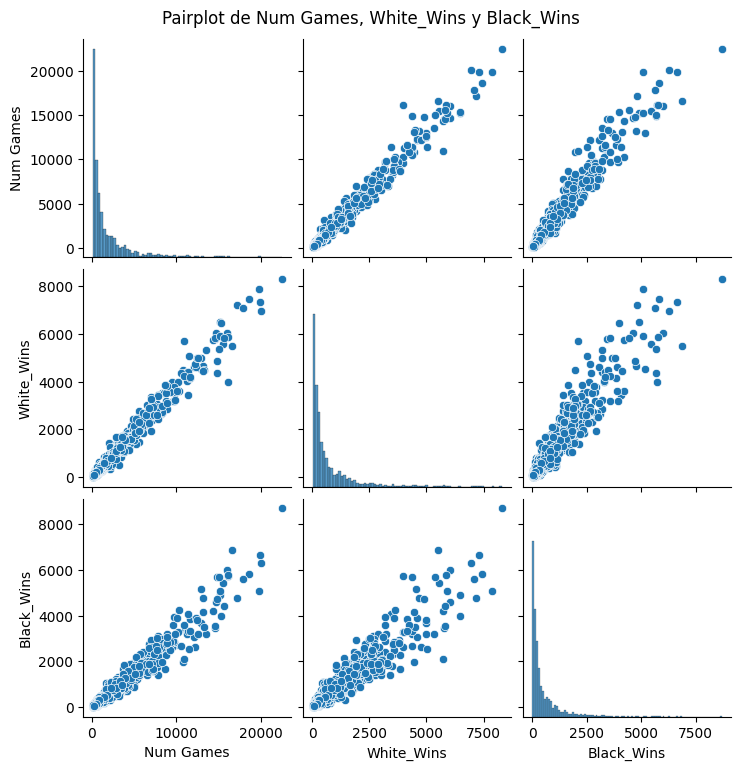

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las variables numéricas con alta correlación
correlated_vars = ['Num Games', 'White_Wins', 'Black_Wins']

# Crear el pairplot
sns.pairplot(df[correlated_vars])
plt.suptitle('Pairplot de Num Games, White_Wins y Black_Wins', y=1.02) # Ajustar el título
plt.show()

### Análisis del Pairplot de 'Num Games', 'White_Wins' y 'Black_Wins'

El `pairplot` posibilita la visualización no solo de las distribuciones individuales, sino también de las relaciones entre las variables numéricas `Num Games`, `White_Wins` y `Black_Wins`, brindando una perspectiva completa del comportamiento del conjunto de datos. En la diagonal, los histogramas revelan que las tres variables tienen una **distribución que se sesga de manera significativa hacia la derecha**, lo cual señala que la mayor parte de las aperturas cuenta con escasos juegos y triunfos, mientras que un grupo reducido acumula valores muy altos. Los gráficos de dispersión muestran **correlaciones lineales positivas y fuertes** entre cada una de las variables fuera de la diagonal: a medida que se incrementa el número de partidas, las victorias de blancas y negras también aumentan en proporción. Asimismo, se percibe una gran concentración de datos en valores bajos y una dispersión creciente hacia valores más altos, lo cual coincide con el sesgo que se identificó.

Estos patrones indican que hay una dependencia sólida entre las variables, lo cual supone cierta redundancia, porque las victorias son un componente del total de juegos disputados. Por lo tanto, a pesar de que estas variables son útiles para examinar la popularidad o el volumen de juego de las aperturas, tienen limitaciones para medir su efectividad relativa. En ese caso, emplear métricas normalizadas, como los porcentajes de victoria, sería más apropiado. De igual manera, el pairplot permite detectar anomalías potenciales, como aperturas con numerosas jugadas pero resultados desequilibrados. Esto podría ser fundamental para realizar análisis más detallados sobre la estrategia y el rendimiento en ajedrez.

###5. Gráfico de violín usando la variable continua categorizada en la Parte 2.

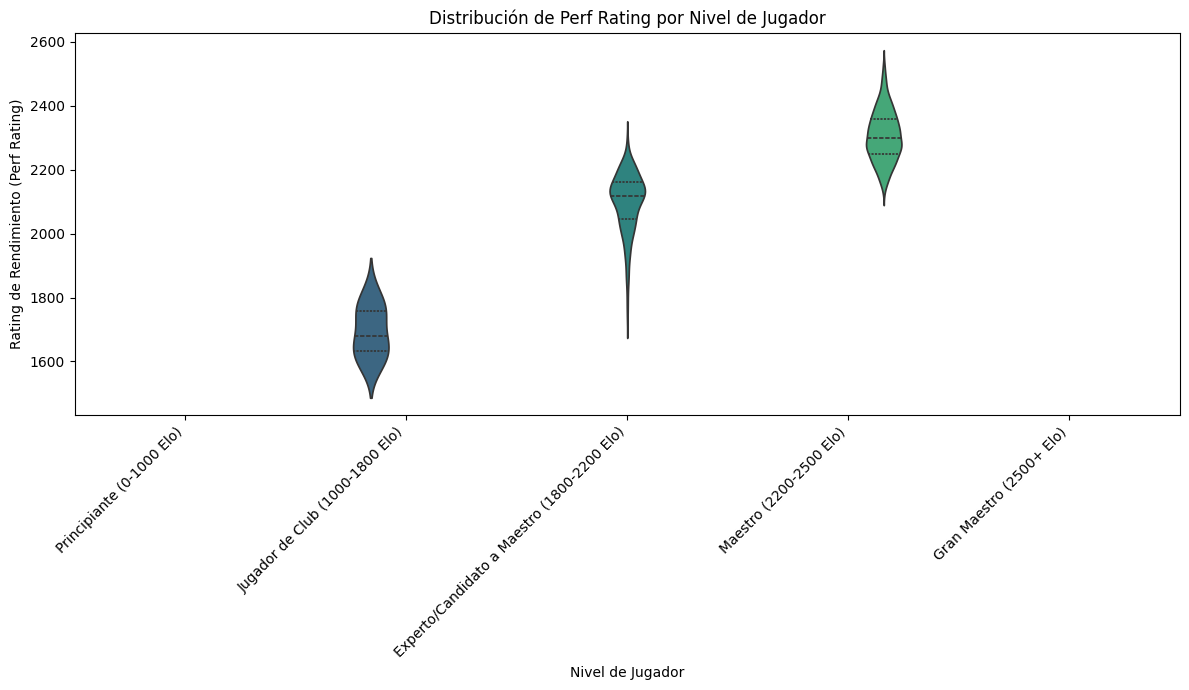

In [ ]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='Player_Level', y='Perf Rating', data=df, inner='quartile', palette='viridis', hue='Player_Level', legend=False)
plt.title('Distribución de Perf Rating por Nivel de Jugador')
plt.xlabel('Nivel de Jugador')
plt.ylabel('Rating de Rendimiento (Perf Rating)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretación del Gráfico de Violín de 'Perf Rating' por 'Player_Level'

El diagrama de violín de Perf Rating, dividido por Player_Level, posibilita el análisis minucioso de la manera en que se distribuye el rendimiento de las aperturas dependiendo del nivel de los jugadores. Se destaca una tendencia de crecimiento, en la que los cuartiles y la mediana del Perf Rating se elevan al avanzar desde niveles como "Principiante" o "Jugador de Club" hasta llegar a "Maestro" y "Gran Maestro". Asimismo, la forma de los violines muestra variaciones en la dispersión: en niveles bajos, son más anchos y extendidos, lo que denota una variabilidad mayor y una experimentación con aperturas de diferente rendimiento; por otro lado, en niveles altos son más angostos y están concentrados en valores altos, lo cual evidencia un uso más constante de aperturas fuertes y optimizadas.

Este comportamiento muestra que existe una relación positiva entre el nivel del jugador y la eficacia de las aperturas empleadas, lo cual indica que los jugadores más experimentados suelen escoger repertorios más pulidos y eficaces. Además, el gráfico posibilita detectar potenciales casos excepcionales, como aperturas con un rendimiento elevado en niveles bajos o reducido en niveles altos, lo cual puede inspirar investigaciones complementarias. En la práctica, esta visualización es útil para guiar procesos de aprendizaje y entrenamiento, pues muestra que adoptar aperturas con un alto Perf Rating, propias de jugadores expertos, puede ser fundamental para mejorar el rendimiento en ajedrez.

###6. Comparación de histogramas de las variables que fueron estandarizadas o escaladas.

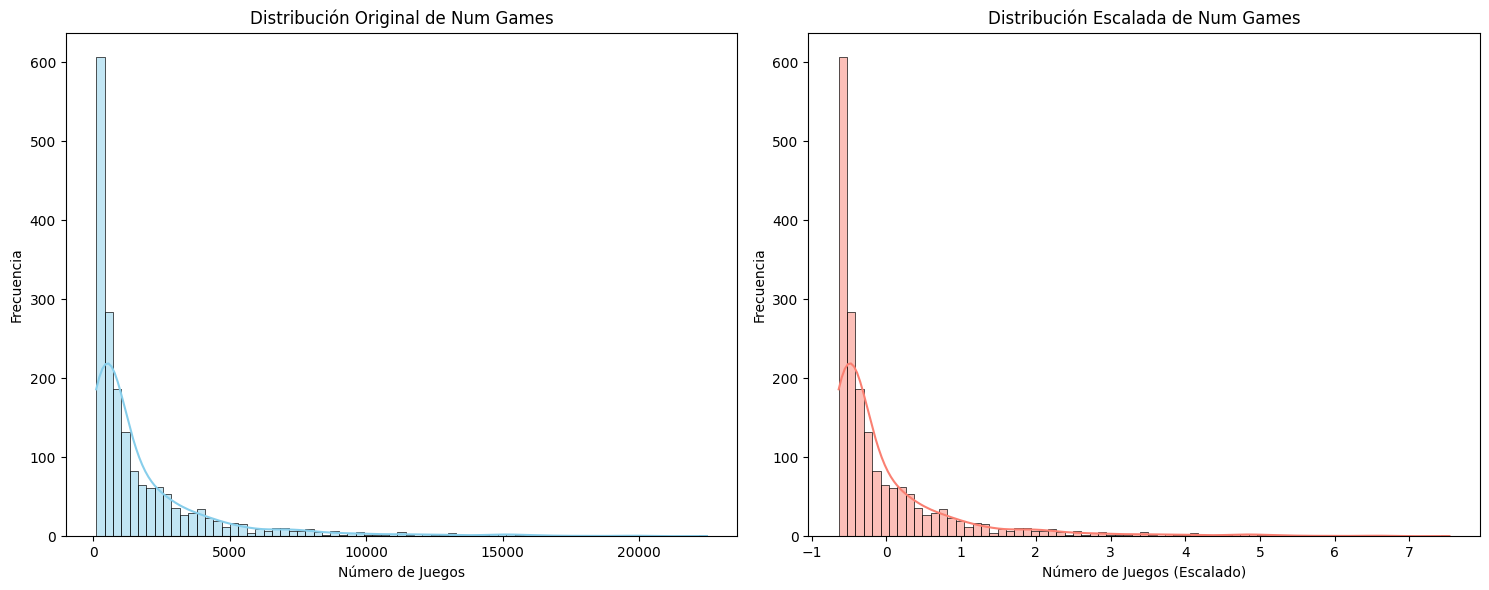

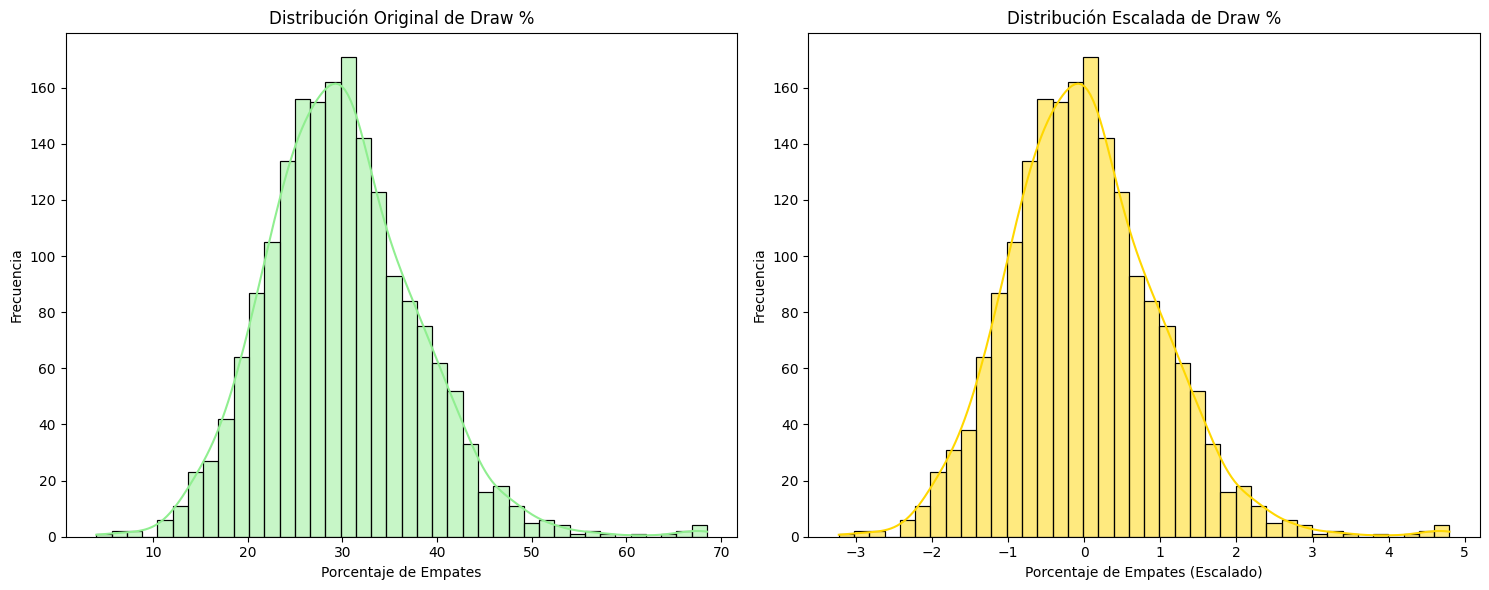

In [ ]:
plt.figure(figsize=(15, 6))

# Histograma de 'Num Games' original
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(df['Num Games'], kde=True, color='skyblue')
plt.title('Distribución Original de Num Games')
plt.xlabel('Número de Juegos')
plt.ylabel('Frecuencia')

# Histograma de 'Num Games' escalado
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.histplot(df['Num Games_scaled'], kde=True, color='salmon')
plt.title('Distribución Escalada de Num Games')
plt.xlabel('Número de Juegos (Escalado)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))

# Histograma de 'Draw %' original
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(df['Draw %'], kde=True, color='lightgreen')
plt.title('Distribución Original de Draw %')
plt.xlabel('Porcentaje de Empates')
plt.ylabel('Frecuencia')

# Histograma de 'Draw %' escalado
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.histplot(df['Draw_percent_scaled'], kde=True, color='gold')
plt.title('Distribución Escalada de Draw %')
plt.xlabel('Porcentaje de Empates (Escalado)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Interpretación de la Comparación de Histogramas (Original vs. Escalado)

Los histogramas de Num Games y Draw % previos y posteriores al escalado con StandardScaler sirven para ver el comportamiento de estas variables y el impacto de la normalización. En el caso de Num Games, la distribución original está sesgada hacia la derecha, lo que señala que la mayoría de las aperturas contienen pocos juegos, pero unas pocas tienen un volumen muy alto. Esto produce una larga cola característica de los datos de popularidad. Draw % tiene, en cambio, una distribución con menor asimetría y más centrada sobre un valor central.Después del escalado, las dos variables mantienen la misma forma de distribución; no obstante, sus valores quedan centrados en una media de 0 y en una desviación estándar de 1. Esto posibilita que cada dato se analice según su distancia a la media.

El StandardScaler no cambia la forma de los datos, sino que los normaliza en su escala; esto es fundamental para el modelado y el análisis. La normalización simplifica la utilización de algoritmos que son sensibles a la magnitud de las variables, previene que rasgos con rangos amplios dominen el modelo, optimiza el cálculo de distancias en métodos como K-Means o KNN, y puede hacer que los algoritmos basados en gradiente converjan más rápido. Además, posibilita una comparación equitativa de la relevancia de diversas variables, aun cuando originalmente tuvieran escalas o unidades distintas; esto es esencial para realizar una interpretación apropiada en modelos de aprendizaje automático.

###7. Gráfico de densidad (opcional) con kdeplot para visualizar la forma de distribución de una o más variables numéricas.

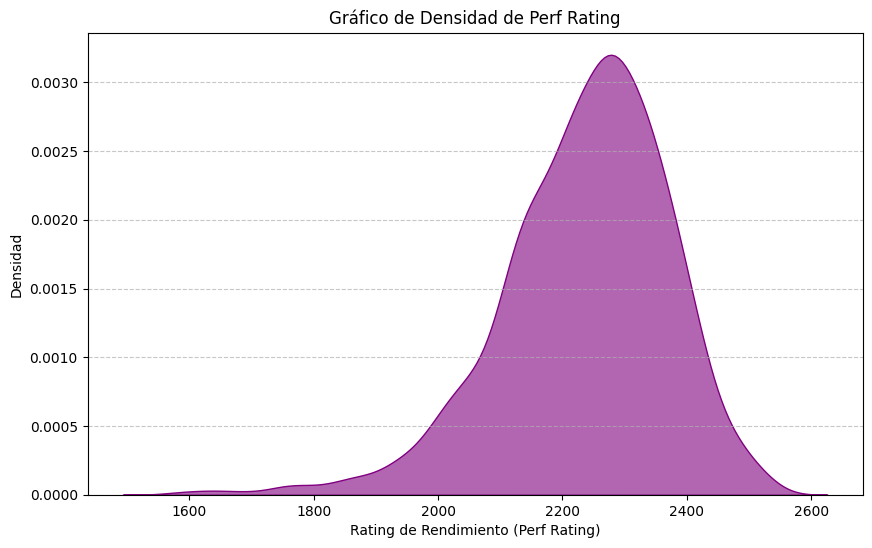

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Perf Rating'], fill=True, color='purple', alpha=0.6)
plt.title('Gráfico de Densidad de Perf Rating')
plt.xlabel('Rating de Rendimiento (Perf Rating)')
plt.ylabel('Densidad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretación del Gráfico de Densidad de 'Perf Rating'

El KDE (gráfico de densidad) de Perf Rating presenta una representación continua y suavizada de cómo se distribuye el rendimiento de las aperturas, lo que posibilita detectar con precisión su forma general, concentración y eventuales asimetrías. La curva permite identificar valles, que son las áreas con menor frecuencia, y picos, que indican los rangos donde se agrupan más aperturas. También es posible averiguar si la distribución tiene un solo pico o varios. Asimismo, si la curva se extiende hacia alguno de los extremos, esto indica la existencia de sesgo: una cola más larga hacia valores altos sugiere un sesgo positivo; en cambio, una cola más larga hacia valores bajos indicaría un sesgo negativo.

Este análisis posibilita deducir la calidad general de las aperturas en el conjunto de datos, porque la posición del pico principal muestra cuál es el rango de rendimiento más frecuente. La presencia potencial de varios picos puede indicar la existencia de diferentes conjuntos de aperturas con características distintas, mientras que el comportamiento en las colas puede ayudar a identificar valores atípicos. En general, el KDE ofrece una perspectiva más fluida que el histograma y es particularmente valioso cuando se compara entre categorías (como color o nivel del jugador), lo cual permite entender de manera más profunda las variaciones que presenta el Perf Rating en distintos contextos.

###8. Gráfico combinado (por ejemplo: barras con hue, scatter con tamaño de punto, etc.) que permita relacionar dos o más dimensiones en un mismo gráfico.

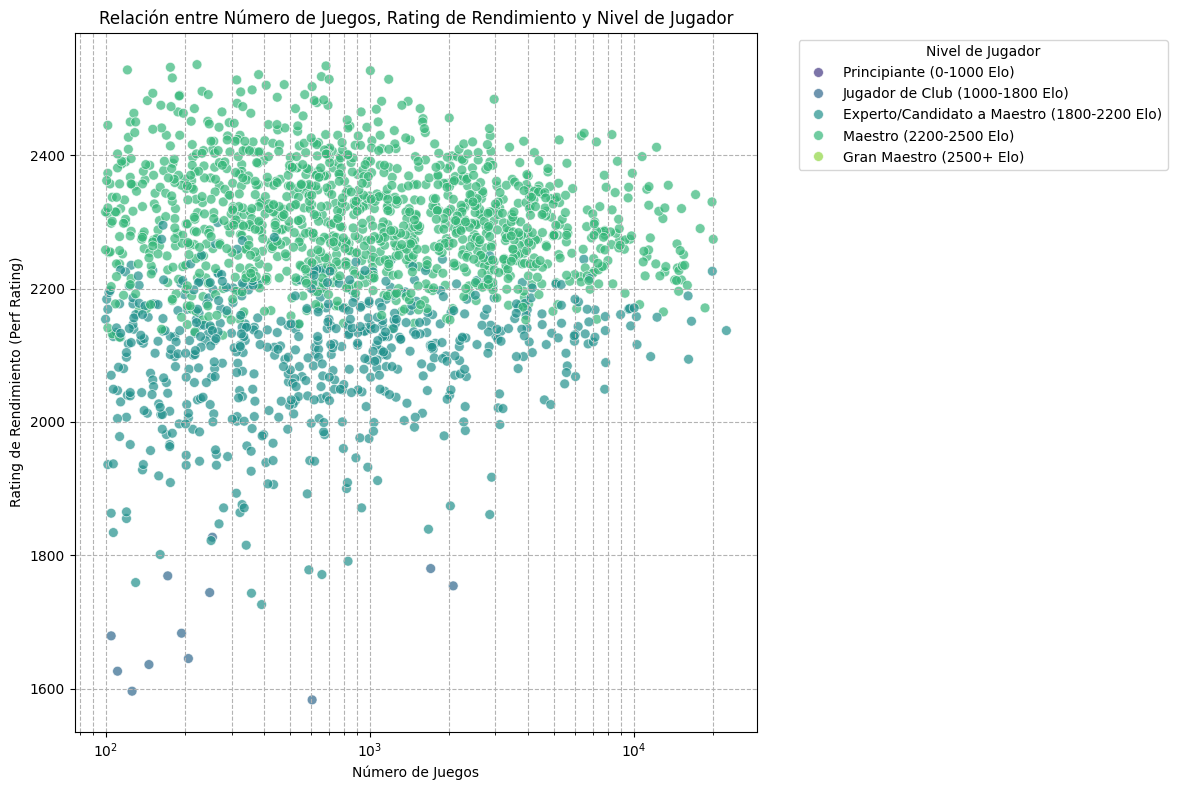

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Num Games', y='Perf Rating', hue='Player_Level', data=df, s=50, alpha=0.7, palette='viridis')
plt.title('Relación entre Número de Juegos, Rating de Rendimiento y Nivel de Jugador')
plt.xlabel('Número de Juegos')
plt.ylabel('Rating de Rendimiento (Perf Rating)')
plt.xscale('log') # Escala logarítmica para manejar el sesgo de 'Num Games'
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Nivel de Jugador', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Análisis del Gráfico Combinado: Número de Juegos, Rating de Rendimiento y Nivel de Jugador

El gráfico de dispersión examina al mismo tiempo la conexión entre Num Games, Perf Rating y Player_Level, lo que ofrece una perspectiva completa del comportamiento de las aperturas. El eje X (en escala logarítmica) posibilita el manejo del marcado sesgo de Num Games, lo que favorece la visualización de aperturas poco jugadas y también de las más populares. Por lo general, se nota una tendencia positiva: el Perf Rating tiende a ser más alto cuando hay un número mayor de partidas, aunque los valores bajos presentan una alta variabilidad. Además, la utilización del color muestra una estratificación evidente según el nivel del jugador. Los niveles superiores (Gran Maestro y Maestro) se ubican en áreas de rendimiento más alto, en tanto que los niveles inferiores están distribuidos en rangos más bajos y dispersos.

Este comportamiento confirma que el nivel de habilidad del jugador influye en el desempeño de las aperturas, lo cual respalda la noción de que los jugadores más experimentados prefieren las líneas más eficientes. También se observa una correlación entre la calidad y la popularidad, puesto que las aperturas más empleadas suelen tener resultados más favorables, aunque no de manera estrictamente lineal. La experimentación es sugerida por una dispersión más amplia en aperturas poco jugadas, especialmente en niveles bajos, donde pueden existir opciones que no son eficientes y otras que sí lo son. Este gráfico, en su totalidad, no solo hace posible comprender la dinámica entre nivel, uso y rendimiento; también ayuda a detectar patrones interesantes y potenciales oportunidades para realizar un análisis más detallado de aperturas sobrevaloradas o subestimadas.

##**Parte 4: Análisis integrador**

Al finalizar el desarrollo del análisis exploratorio, redacte una celda Markdown donde integre y reflexione sobre los hallazgos obtenidos. Este análisis debe incluir:

*	**Resumen de hallazgos:** Principales resultados obtenidos a lo largo de las partes anteriores.

*	**Relación con los objetivos:** Verificación de si los resultados responden a los objetivos planteados.





*	**Interpretación crítica:** Posibles explicaciones de patrones, correlaciones o valores atípicos observados.
*	**Aplicabilidad:** Utilidad del análisis en su contexto profesional, académico o social.
*	**Limitaciones:** Restricciones encontradas y sugerencias para futuros análisis.


## Análisis Integrador del Exploratorio de Datos (EDA)



El Análisis Exploratorio de Datos (EDA) aplicado a las aperturas de ajedrez permitió comprender mejor la composición y las tendencias presentes en el conjunto de datos. Las variables cuantitativas, como Num Games, White_Wins y Black_Wins, evidenciaron una gran dispersión y una distribución sesgada hacia valores altos, lo que refleja que unas pocas aperturas reúnen la mayor cantidad de partidas, mientras que la mayoría son poco utilizadas. Además, la identificación de valores atípicos confirmó la presencia de aperturas especialmente influyentes dentro del juego. En las variables categóricas (ECO, move1w y move1b) se observó una clara concentración en ciertos códigos y movimientos iniciales tradicionales, como e4 y Nf6. Posteriormente, se realizó el preprocesamiento de los datos mediante técnicas de categorización, normalización y codificación, destacando la creación de Player_Level para clasificar a los jugadores según su nivel, el uso de StandardScaler para ajustar escalas numéricas y la aplicación de LabelEncoder para convertir variables categóricas en valores numéricos. Finalmente, las distintas visualizaciones estadísticas facilitaron la interpretación de los resultados, permitiendo identificar relaciones entre partidas y victorias, reconocer la concentración de aperturas más populares y comprobar que las aperturas con mejor desempeño suelen estar asociadas a jugadores de niveles más avanzados

### Objetivos:



*   **Analisis del uso de los movimientos f3 y g4 en niveles de juego superiores al principiante:** Mediante la categorización de `Avg Player` en `Player_Level` y el análisis de la distribución de `Perf Rating` por nivel, así como la inspección de los movimientos iniciales (`move1w`, `move1b`), se observó que estos movimientos (`f3`, `g4`) no figuran entre los más comunes en ningún nivel significativo, sugiriendo que no son populares en niveles superiores, esto se debe a consideraciones estratégicas, estos dos movimientos se consideran los mas debiles y no es ilogico concluir que los jugadores consideran la perdida de turno realizarlos.
*   **Determinar la apertura más usada por los jugadores analizados en el dataset:** El análisis de frecuencias de códigos ECO (`eco_counts` en el gráfico de barras) y de los primeros movimientos (`move1b_counts` en el gráfico de pie) identificó `A00` como el código ECO más frecuente y el segundo codigo mas frecuente `B00` seguido por `B01` es decir los jugadores analizados tendieron a utilizar aperturas que priorizan los flancos en caso de las blancas reconocido por las aperturas `A**`y en caso de las negras las aperturas `B**` inidican defensas que no luchan directamente en el centro estas aperturas se salen del concepto teorico basico y requieren tanto un mayor conocimiento teorico como un mayor analsis en el tablero ya que se tiende aperder vision de los extremos del tablero causando que jugadores con poca experiencia se vean mas expuestos a ataque de piezas como los alfiles y caballos piezas cuyo movimiento jugadores tienden a clacular de manera erronea ma aun bajo presion.
*   **Comprobar si las aperturas más usadas toman el centro del tablero:** El estudio de los primeros movimientos más frecuentes (`e4`, `d4`, `c4`, `Nf3` para blancas y `e5`, `d5`, `c5`, `Nf6` para negras) reveló una fuerte inclinación por los movimientos de peones centrales (`e4`, `d4`, `e5`, `d5`) y los desarrollos de caballo que influyen en el centro. Esto confirma que las aperturas más populares, en su mayoría, sí buscan controlar el centro del tablero.


### Interpretación Crítica:

La fuerte correlación entre `Num Games`, `White_Wins` y `Black_Wins` refleja una redundancia natural en los datos, indicando que las métricas absolutas aportan menos información sobre la calidad real de una apertura que las métricas relativas, como `White_win%` y `Black_win%`, ya que una apertura muy jugada no necesariamente es mejor, sino simplemente más popular. Asimismo, los outliers identificados en `Num Games` no representan errores estadísticos, sino aperturas ampliamente estudiadas y utilizadas, evidenciando la concentración del conocimiento teórico en un número reducido de líneas y afectando medidas como la media y la desviación estándar. Finalmente, la segmentación del `Perf Rating` según `Player_Level` muestra una tendencia clara: los jugadores de mayor nivel tienden a utilizar aperturas más sólidas y efectivas, lo que sugiere un consenso competitivo sobre cuáles ofrecen mejores resultados, mientras que las aperturas menos populares y con bajo rendimiento podrían carecer de suficiente desarrollo teórico o presentar menor solidez estratégica.


### Aplicabilidad:

Este EDA proporciona información valiosa con múltiples aplicaciones prácticas, tanto en el ámbito competitivo como académico del ajedrez. Para los jugadores, puede servir como guía en la selección de aperturas según su nivel y estilo de juego, ayudando a principiantes a evitar líneas complejas y permitiendo a jugadores avanzados explorar variantes menos populares pero con alto Perf Rating. En el caso de los desarrolladores de motores de ajedrez, los resultados pueden contribuir a optimizar los libros de aperturas al priorizar líneas eficientes y ampliamente utilizadas, así como identificar variantes con potencial estratégico. Asimismo, para analistas y teóricos del ajedrez, el estudio facilita la identificación de tendencias, la evolución de preferencias en las aperturas y el impacto de nuevas ideas en la popularidad y efectividad de determinadas líneas. Finalmente, en un contexto académico y educativo, este análisis constituye una herramienta útil para enseñar teoría de aperturas y aplicar conceptos estadísticos en un entorno práctico y atractivo, promoviendo el análisis crítico de datos relacionados con el ajedrez.

### Limitaciones y Sugerencias para Futuros Análisis:

Aunque el análisis realizado ofrece hallazgos relevantes, existen algunas limitaciones y oportunidades de mejora. En primer lugar, las variables White_Wins y Black_Wins no integran explícitamente los empates, por lo que un análisis conjunto de Win%, Loss% y Draw% permitiría comprender de forma más completa el desempeño real de las aperturas. Además, para variables categóricas con alta cardinalidad, como ECO u Opening, sería más adecuado emplear técnicas como One-Hot Encoding en lugar de LabelEncoder, evitando así introducir relaciones de orden artificial en futuros modelos predictivos. Asimismo, el estudio se centra principalmente en los primeros movimientos de la partida, cuando en realidad las aperturas se desarrollan a lo largo de varias jugadas; por ello, incorporar secuencias más extensas (move2w, move2b, etc.) podría revelar patrones estratégicos más complejos. Finalmente, es importante destacar que las correlaciones observadas no implican causalidad: una apertura no obtiene un alto Perf Rating por ser popular, sino que tanto su popularidad como su rendimiento probablemente derivan de su solidez estratégica y de su constante perfeccionamiento por jugadores experimentados.


### Conclusiones personales

Los objetivos planteados respondieron a preguntas que personalmente me he hecho desde que juego ajedrez tomando en cuenta la teoria mi primera pregunta fue existe una jugada inicial de blancas que se considere que no hay una linea de jugadas que pueda recuperar el juego y el anlisis de todo el dataset brinda la respuesta f3 y g4 efectivamente son las unicas jugadas de peon que ningun jugador realizo.

Mi segunda pregunta surge de que mis aperturas usadas son la española, italiana y sus variaciones por esto me pregunte en niveles mas avanzados estas aperturas son muy usadas y la respuesta fue negativa pero su respuesta permite observar ataques al centro del tablero sin usos de la columna central.

y por ultimo me pregunte si tratar de controlar el centro por medio de los peones es realizado por los jugadores la respuesta es positiva pero la respuesta de esta pregunta de movimientos iniciales revela que no siempre se debe buscar el control con las piezas obvias los peones que tambien los caballos cumplen esta funcion y por su movimiento es mas dificil ver donde estan controlando.

#**Referencias en APA.**
Downey, A. B. (2015). *Think Python: How to think like a computer scientist (2nd ed.)*. O’Reilly Media. (pp. 1-26, 39-69).

McKinney, W. (2022). *Python for data analysis: Data wrangling with pandas, NumPy, and Jupyter (3rd ed.)*. O’Reilly Media. (pp. 1-46).

El Análisis Exploratorio de Datos (EDA) sobre aperturas de ajedrez permitió identificar patrones clave en la estructura y el comportamiento del *dataset*. En primer lugar, se evidenció que variables como `Num Games`, `White_Wins` y `Black_Wins` presentan alta variabilidad y un fuerte sesgo a la derecha, lo que indica que pocas aperturas concentran la mayoría de las partidas, mientras que la mayoría tiene baja frecuencia. La presencia de *outliers* confirma la existencia de aperturas altamente populares, fundamentales en el estudio del ajedrez. Asimismo, las variables categóricas (`ECO`, `move1w`, `move1b`) muestran una distribución desigual, destacando códigos como **A00** y movimientos clásicos como **e4, d4, Nf6 o c5**, lo que refleja una clara preferencia por líneas sólidas y tradicionales. En cuanto a la preparación de datos, la categorización en `Player_Level` permitió analizar el rendimiento según el nivel de habilidad, mientras que la estandarización con `StandardScaler` facilitó el uso en modelos sin alterar la forma de las distribuciones, y la codificación de variables categóricas permitió su integración en análisis numéricos.

Desde el punto de vista visual, los gráficos confirmaron y ampliaron estos hallazgos: los diagramas de barras y de pastel evidenciaron la concentración en pocas aperturas y movimientos; el boxplot de `Black_win%` mostró dispersión y valores atípicos relevantes; el `pairplot` confirmó correlaciones fuertes entre variables de conteo, sugiriendo redundancia; el *violin plot* evidenció que el `Perf Rating` aumenta con el nivel del jugador; los histogramas escalados validaron el efecto del preprocesamiento; el KDE permitió analizar la forma de la distribución del rendimiento; y el *scatter plot* integró variables mostrando que las aperturas más populares y efectivas son usadas principalmente por jugadores avanzados. En relación con los objetivos, se determinó que movimientos como **f3** y **g4** no son comunes en niveles altos, se identificaron las aperturas más utilizadas (como A00) y se confirmó que las más populares tienden a controlar el centro del tablero. Finalmente, el análisis destaca aplicaciones prácticas para jugadores, analistas y desarrolladores, aunque presenta limitaciones como la falta de contexto del *dataset*, ausencia de análisis temporal y necesidad de métricas relativas, abriendo oportunidades para futuros estudios más profundos.